In [ ]:
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde
import torch 
from torch import Tensor

import deep_tensor as dt

from examples.plotting import set_plot_style
from examples.sir import SIRCompartmentModel, build_periodic_adjacency

In [2]:
torch.manual_seed(0)
torch.set_default_device("cuda" if torch.cuda.is_available() else "cpu")
set_plot_style()

In [3]:
num_compartments = 3
dim = 2 * num_compartments

adjacency_matrix = build_periodic_adjacency(num_compartments)

S0 = torch.arange(100-num_compartments, 100)
I0 = 100 - S0
R0 = torch.zeros((num_compartments,))

# Define timespan and evaluation times
t1 = 5.0
t_eval = torch.linspace(0, 5, 25*6+1)
inds_obs = torch.arange(0, 25*6+1, 25)

model = SIRCompartmentModel(adjacency_matrix, S0, I0, R0, t_eval, inds_obs)

In [4]:
true_param = torch.tensor([[0.1, 1.0] * num_compartments])

# Properties of likelihood
std_noise = 1.0

ys_true = model.get_obs(model.solve(true_param))
ys_obs = ys_true # + std_noise * torch.randn_like(ys_true)


def neglogpost(xs: Tensor) -> Tensor:
    # Note: prior is uniform
    ys = model.get_obs(model.solve(xs))
    neglogliks = (ys-ys_obs).square().sum(dim=1) / (2*std_noise**2)
    return neglogliks

In [5]:
# Define rare event threshold
I_max = 88.0

In [6]:
domain = dt.BoundedDomain([-3.0, 3.0])
reference = dt.GaussianReference(domain)
bounds = torch.tensor([[0.0, 2.0]]).tile((dim, 1))
preconditioner = dt.UniformMapping(bounds=bounds, reference=reference)

basis = dt.Lagrange1(num_elems=17)
# basis = dt.Fourier(order=8)
# basis = dt.Legendre(order=17)

tt_options = dt.TTOptions(max_als=1, init_rank=7, tt_method="fixed_rank", verbose=2)

tt = dt.TT(tt_options)
ftt = dt.FTT(basis, tt)

# Denominator

betas = 10 ** torch.linspace(-3.0, 0.0, 10)
betas = betas.tolist()
bridge = dt.Tempering(betas)

posterior = dt.TargetFunc(neglogpost)

dirt = dt.DIRT(posterior, preconditioner, ftt, bridge)

[DIRT] Iter:  1 | Cum. Fevals: 1.00e+03 | Cum. Time: 6.17e-01 s | Beta: 0.0010 | DHell: 0.0000 | ESS: 0.7064
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       4780 |        7 |       1.00e+00 |        1.00e+00 | 3.03e-02
[ALS]  ALS complete.
[ALS]  Maximum TT rank: 7.
[DIRT] Iter:  2 | Cum. Fevals: 6.78e+03 | Cum. Time: 4.92e+00 s | Beta: 0.0022 | DHell: 0.0194 | ESS: 0.8067
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       4780 |        7 |       3.26e-01 |        8.79e-02 | 2.42e-02
[ALS]  ALS complete.
[ALS]  Maximum TT rank: 7.
[DIRT] Iter:  3 | Cum. Fevals: 1.26e+04 | Cum. Time: 8.15e+00 s | Beta: 0.0046 | DHell: 0.0236 | ESS: 0.6540
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       4780 |        7 |       1.47e-01 |        8.54e-02 | 2.97e-02
[ALS]  ALS complete.
[ALS]  Maximum TT rank: 7.
[DIRT] Iter:  4 | Cum. Fevals: 1.83e+

In [7]:
num_samples = 1_000_000

rs = dirt.reference.random(n=num_samples, d=dim)
xs, neglogfxs_dirt = dirt.eval_irt(rs)

In [8]:
neglogfxs_exact = neglogpost(xs)

In [9]:
res = dt.run_independence_sampler(xs, neglogfxs_dirt, neglogfxs_exact)

In [10]:
res.iacts

tensor([[1.1874, 1.1778, 1.2086, 1.1779, 1.2103, 1.1832]])

In [21]:
xs = res.xs[0, ::2, :]

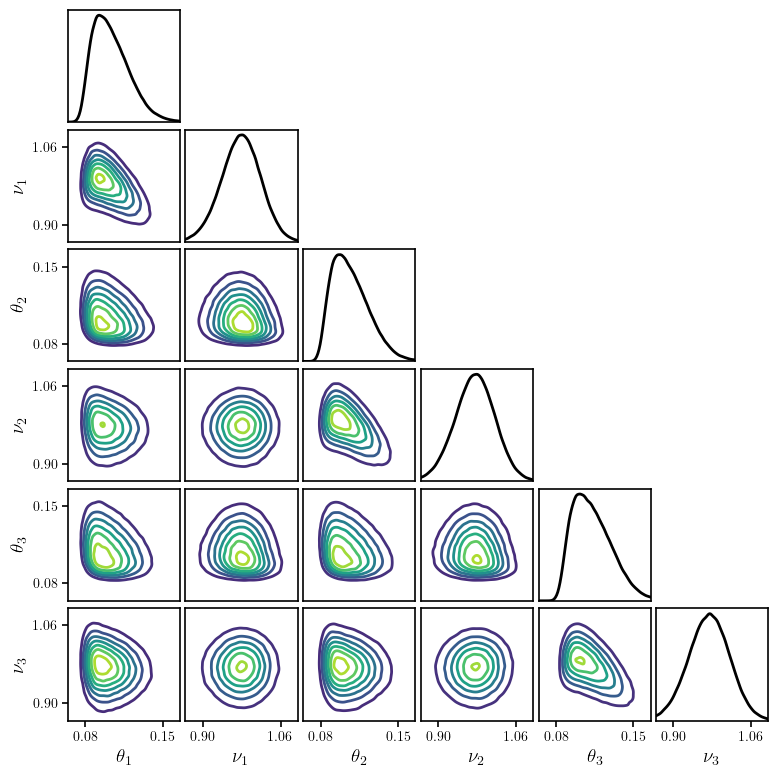

In [22]:
fig, axes = plt.subplots(nrows=xs.shape[1], ncols=xs.shape[1], figsize=(8, 8))
ticks = [
    [0.08, 0.15], 
    [0.90, 1.06],
    [0.08, 0.15], 
    [0.90, 1.06],
    [0.08, 0.15], 
    [0.90, 1.06]
]
dxs = [b[1]-b[0] for b in bounds]
bounds = [
    [ticks[i][0]-0.15*dxs[i], ticks[i][1]+0.15*dxs[i]]
    for i in range(dim)
]

n = 100

for i in range(xs.shape[1]):
    for j in range(i):

        xis, xjs = xs[:, j], xs[:, i]
        data = torch.vstack((xis, xjs))

        kde = gaussian_kde(data.numpy())

        is_ = torch.linspace(bounds[j][0], bounds[j][1], n).tile(n, 1)
        js_ = torch.linspace(bounds[i][0], bounds[i][1], n).tile(n, 1).T
        ijs = torch.vstack((is_.flatten(), js_.flatten()))
        zs = kde(ijs.numpy()).reshape(n, n)

        axes[i][j].contour(is_, js_, zs)

        axes[i][j].set_yticks(ticks[i])
        axes[i][j].set_xticks(ticks[j])
        # axes[i][j].tick_params(axis="both", direction="in")

for ax in axes.flat:
    ax.set_box_aspect(1)

for i in range(xs.shape[1]):
    for j in range(i+1):
        if j > 0 or i == 0:
            axes[i][j].set_yticks([])
        if i != dim - 1:
            axes[i][j].set_xticks([])

for i in range(xs.shape[1]):
    kde = gaussian_kde(xs[:, i].numpy())
    is_ = torch.linspace(bounds[i][0], bounds[i][1], n)
    axes[i][i].plot(is_, kde(is_), c="k")
    axes[i][i].set_xlim(bounds[i])
    axes[i][i].set_ylim(bottom=0.0)
axes[dim-1][dim-1].set_xticks(ticks[dim-1])

for i in range(xs.shape[1]):
    for j in range(i+1, dim):
        axes[i][j].set_xlim(bounds[i])
        axes[i][j].set_ylim(bounds[j])
        axes[i][j].set_axis_off()

for i in range(dim):
    label = (r"$\theta_{" if i%2==0 else r"$\nu_{") + f"{(i+2)//2}" + r"}$"
    if i > 0:
        axes[i][0].set_ylabel(label)
    axes[dim-1][i].set_xlabel(label)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig("posterior.pdf")